<a href="https://colab.research.google.com/github/M-AyyanAsif/NETSOL_TASKS/blob/main/Netsol_EDA_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
sns.set (style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "/content/data.csv"
print(f"Loading data from: {url}\n")

# Load the dataset
df = pd.read_csv(url)

Loading data from: /content/data.csv



In [3]:
print("--- Sample 10 Rows ---")
display(df.sample(10))

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Column Information & Data Types ---")
df.info()
print("\n")


# 3. DATA CLEANING & VALIDATION
# ==========================================
print("--- Missing Values Count ---")
print(df.isnull().sum(), "\n")


--- Sample 10 Rows ---


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
164286,164287,Male,23,1,8.0,0,< 1 Year,Yes,39019.0,152.0,102,0.0
21593,21594,Female,24,1,50.0,1,< 1 Year,No,23875.0,160.0,266,0.0
100648,100649,Male,71,1,28.0,0,1-2 Year,Yes,40208.0,122.0,234,0.0
41843,41844,Male,34,1,28.0,0,1-2 Year,Yes,46090.0,124.0,141,0.0
51552,51553,Female,26,1,37.0,1,< 1 Year,No,34408.0,152.0,58,0.0
46280,46281,Female,22,1,44.0,1,< 1 Year,No,31709.0,152.0,12,0.0
80310,80311,Male,57,1,28.0,0,1-2 Year,Yes,33741.0,26.0,32,0.0
58796,58797,Male,24,1,37.0,0,< 1 Year,Yes,38900.0,151.0,155,0.0
201019,201020,Male,24,1,23.0,1,< 1 Year,No,31206.0,152.0,252,0.0
13638,13639,Female,27,1,28.0,1,< 1 Year,No,31379.0,152.0,281,0.0



--- Dataset Shape ---
Rows: 206002, Columns: 12

--- Column Information & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206002 entries, 0 to 206001
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    206002 non-null  int64  
 1   Gender                206002 non-null  object 
 2   Age                   206002 non-null  int64  
 3   Driving_License       206002 non-null  int64  
 4   Region_Code           206002 non-null  float64
 5   Previously_Insured    206002 non-null  int64  
 6   Vehicle_Age           206002 non-null  object 
 7   Vehicle_Damage        206002 non-null  object 
 8   Annual_Premium        206002 non-null  float64
 9   Policy_Sales_Channel  206002 non-null  float64
 10  Vintage               206002 non-null  int64  
 11  Response              206001 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 18.9+ MB


--- Mi

In [4]:
# Remove null values
df = df.dropna()
print(f"--- Shape after dropping nulls: {df.shape} ---\n")

print("--- Duplicate Rows Count ---")
print(df.duplicated().sum(), "\n")

--- Shape after dropping nulls: (206001, 12) ---

--- Duplicate Rows Count ---
0 



In [5]:
if 'id' in df.columns:
    df = df.drop('id', axis=1)

In [6]:
df.head(5)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1.0
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0.0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1.0
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0.0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0.0


In [7]:
print("--- Statistical Summary of Numerical column ---")
display(df.describe())

print("\n--- Statistical Summary of Categorical column ---")
display(df.describe(include=['object', 'category']))

--- Statistical Summary of Numerical column ---


,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,206001.000000,206001.000000,206001.000000,206001.000000,206001.000000,206001.000000,206001.000000,206001.000000
mean,38.797719,0.997908,26.391139,0.456658,30522.776273,112.129286,154.388401,0.122621
std,15.495814,0.045693,13.227232,0.498119,17221.550153,54.146208,83.682767,0.328002
min,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,24389.000000,29.000000,82.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,31619.000000,135.000000,154.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,39351.000000,152.000000,227.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000



--- Statistical Summary of Categorical column ---


,Gender,Vehicle_Age,Vehicle_Damage
count,206001,206001,206001
unique,2,3,2
top,Male,1-2 Year,Yes
freq,111307,108148,104175


In [8]:
numerical_cols = ['Age', 'Annual_Premium', 'Vintage']
categorical_cols = ['Gender', 'Driving_License', 'Previously_Insured',
                    'Vehicle_Age', 'Vehicle_Damage', 'Response']

Generating Categorical Distributions (Close plot window to continue)...


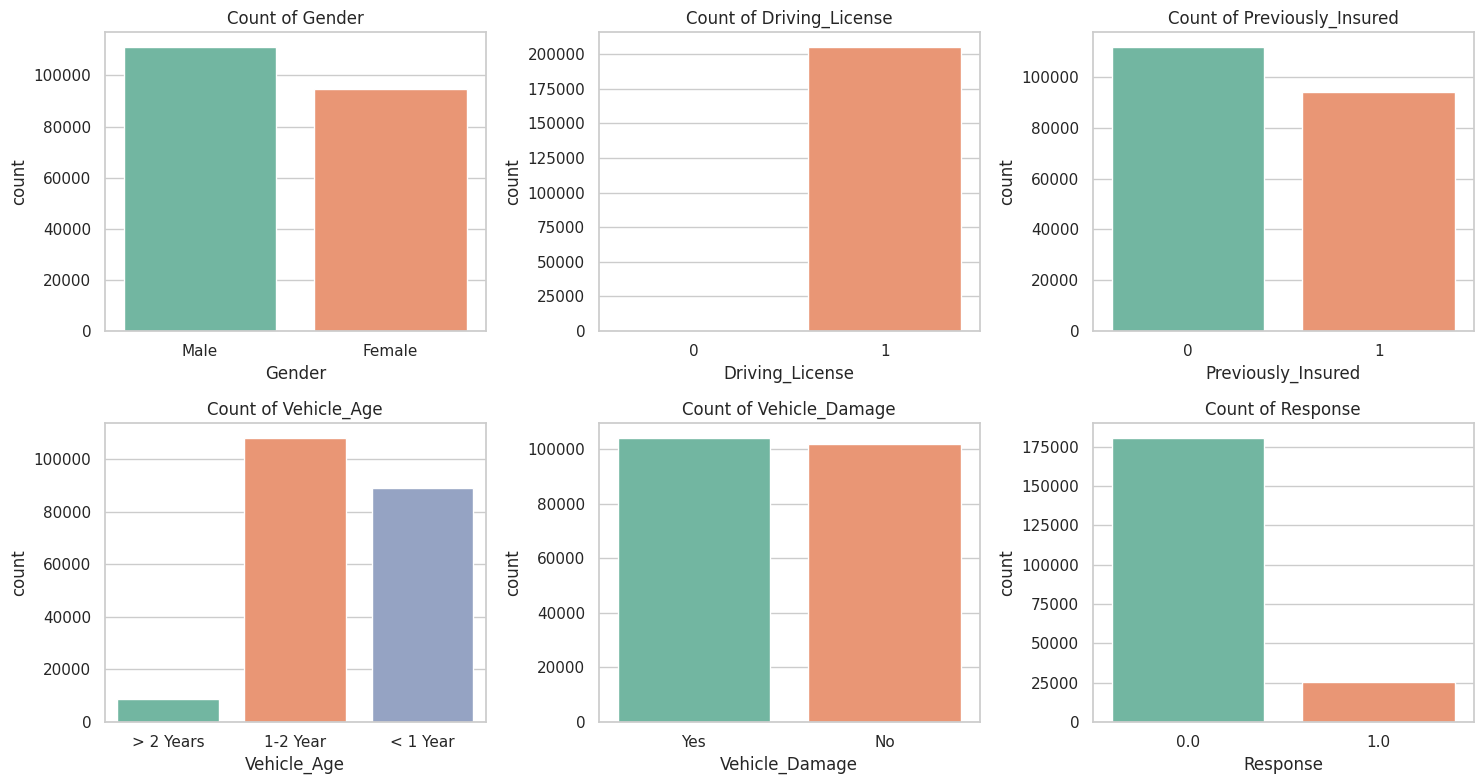

In [9]:
print("Generating Categorical Distributions (Close plot window to continue)...")
plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, palette="Set2")
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()


Generating Numerical Distributions ...


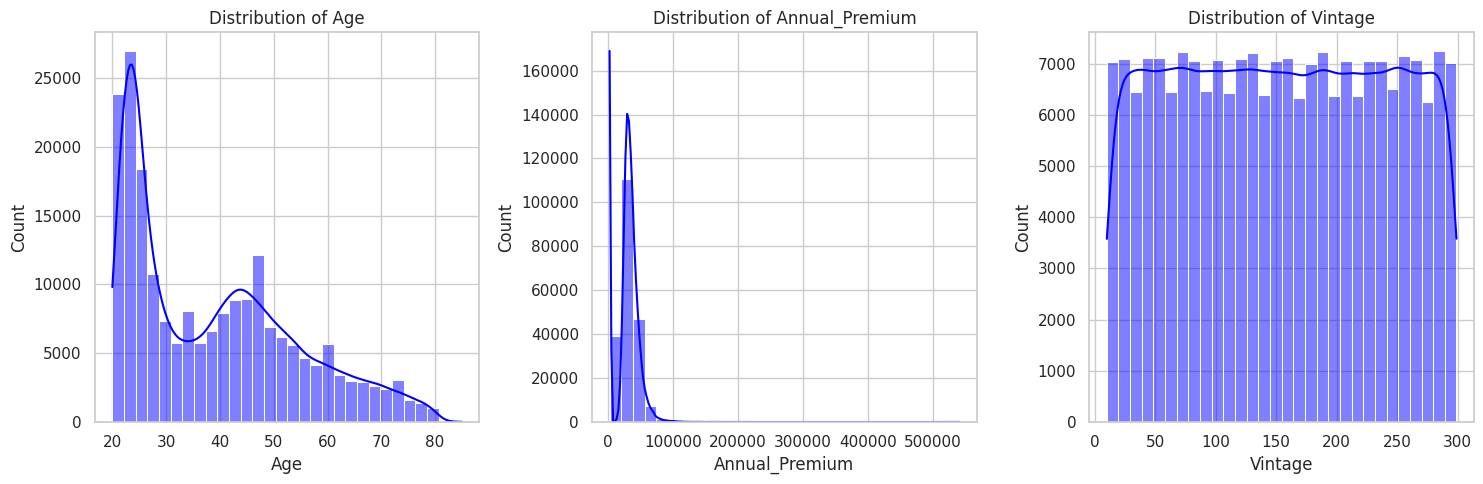

In [10]:
# 5. UNIVARIATE ANALYSIS
print("\nGenerating Numerical Distributions ...")
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [11]:
df['Response'].value_counts()

,count
Response,
0.0,180741
1.0,25260


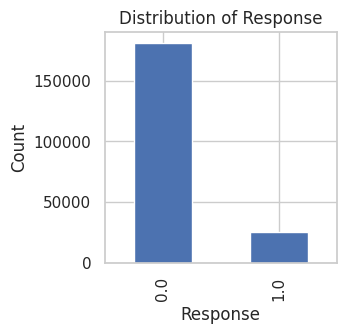

In [12]:
value_count = df['Response'].value_counts()
plt.figure(figsize=(3,3))

value_count.plot(kind= 'bar')
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Response')

plt.show()

<Axes: >

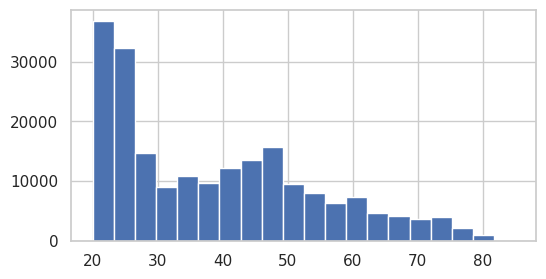

In [13]:
plt.figure(figsize=(6,3))
df['Age'].hist(bins=20)

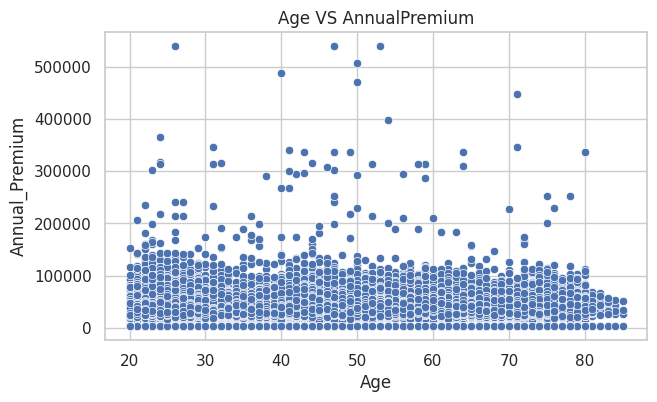

In [14]:
plt.figure(figsize=(7,4))
sns.scatterplot(x='Age', y='Annual_Premium', data=df)
plt.xlabel('Age')
plt.ylabel('Annual_Premium')
plt.title("Age VS AnnualPremium")
plt.show()

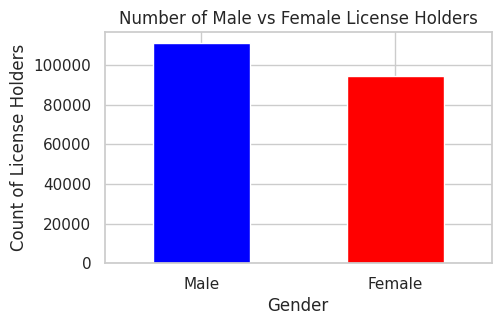

In [15]:
license_holders = df[df['Driving_License'] == 1]
gender_count = license_holders['Gender'].value_counts()

plt.figure(figsize=(5, 3))
gender_count.plot(kind='bar', color=['blue', 'red'])
plt.title('Number of Male vs Female License Holders')
plt.xlabel('Gender')
plt.ylabel('Count of License Holders')
plt.xticks(rotation=0)
plt.show()

Generating Boxplots: Numerical vs Target (Close plot window to continue)...


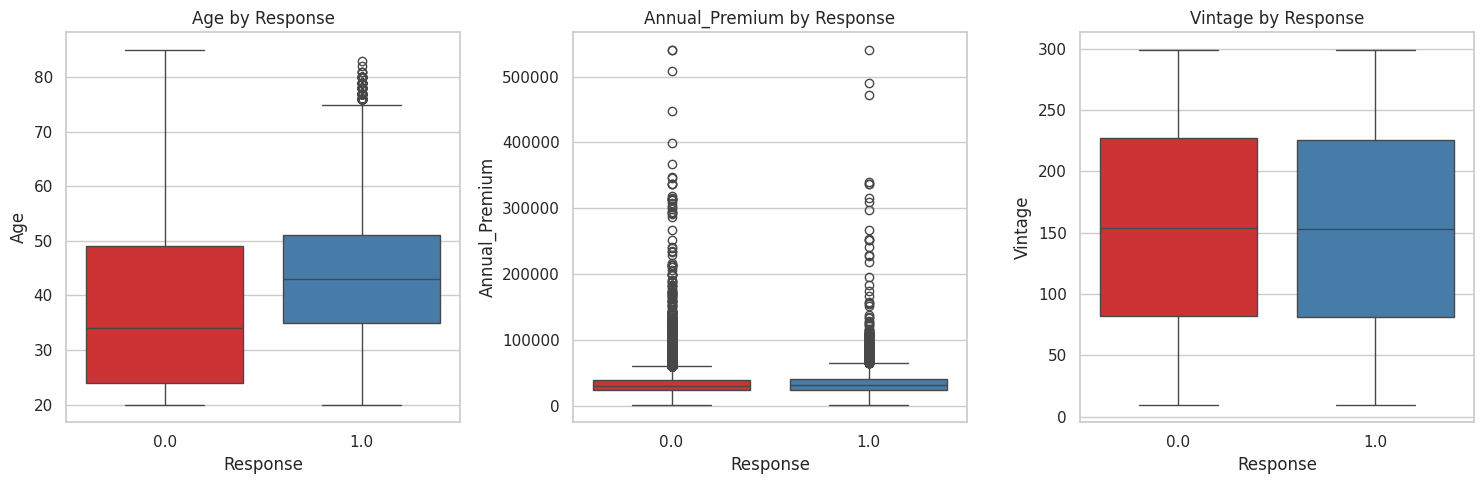

In [16]:
# 6. BIVARIATE ANALYSIS
print("Generating Boxplots: Numerical vs Target (Close plot window to continue)...")
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x='Response', y=col, palette="Set1")
    plt.title(f'{col} by Response')
plt.tight_layout()
plt.show()

Generating Categorical vs Target Plots (Close plot window to continue)...


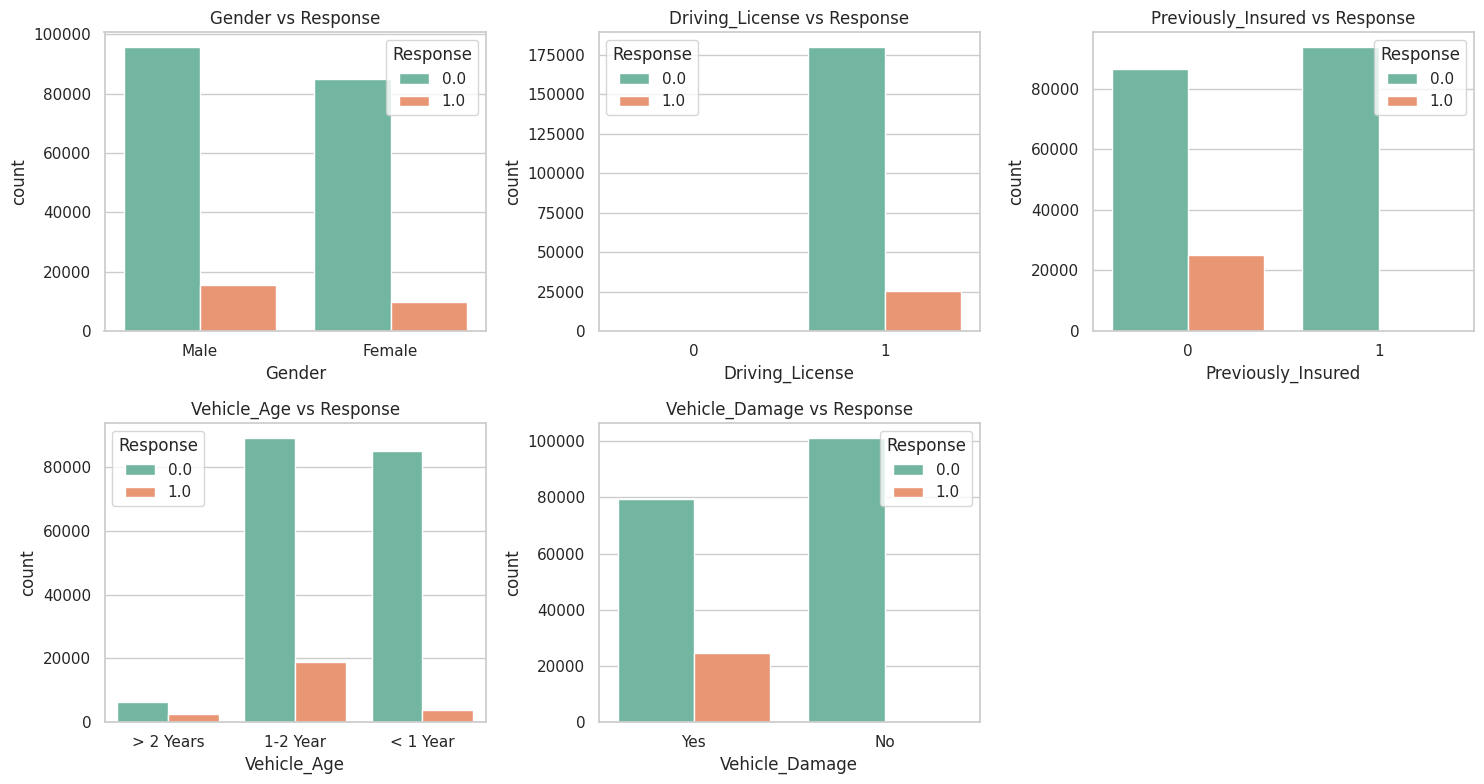

In [17]:
cat_features = [col for col in categorical_cols if col != 'Response']
print("Generating Categorical vs Target Plots (Close plot window to continue)...")
plt.figure(figsize=(15, 8))
for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, hue='Response', palette="Set2")
    plt.title(f'{col} vs Response')
plt.tight_layout()
plt.show()

Generating Correlation Heatmap (Close plot window to finish)...


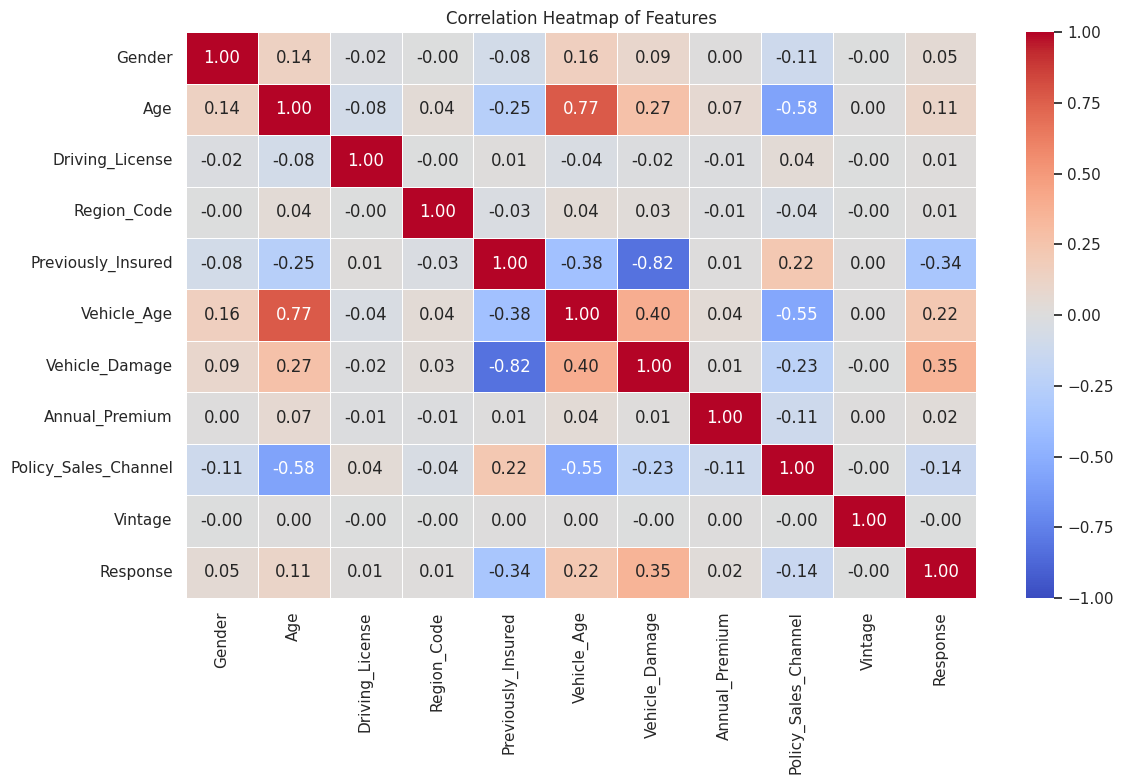

In [18]:
# 7. MULTIVARIATE ANALYSIS & CORRELATION
# ==========================================
print("Generating Correlation Heatmap (Close plot window to finish)...")
df_encoded = df.copy()

# Encode text-based categorical columns to integers so they can be correlated
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})
df_encoded['Vehicle_Damage'] = df_encoded['Vehicle_Damage'].map({'Yes': 1, 'No': 0})
df_encoded['Vehicle_Age'] = df_encoded['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})

# Compute Pearson correlation matrix
corr_matrix = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()